# eIRWR, step by step: a beginner's guide to Section 3

This notebook walks through **Section 3 (Proposed Method)** of the paper
*"eIRWR: Enhanced Iterative Random Walk with Restart for Scalable Root Cause
Analysis in Microservices"* using a tiny 4-service example that you can compute
almost by hand.

**The problem.** A modern application is made of many small *microservices*
that call each other. When one service breaks, the failure *cascades*: services
that depend on it (directly or indirectly) also start looking sick. Monitoring
then shows anomalies **everywhere**, and the on-call engineer has to answer one
question fast: *which service started it?* That is **Root Cause Analysis (RCA)**.

**The trap.** The root cause is often *not* the service with the loudest alarm.
Downstream victims frequently scream louder than the quiet source. So simply
sorting services by anomaly score fails.

**The plan of this notebook** (mirroring Section 3 of the paper):

| Part | Paper section | What you'll learn |
|---|---|---|
| 1. Graph construction | §3.1–3.2 | Turning traces into a weight matrix $W$, and the resilience-damped matrix $M_R$ |
| 2. Basic IRWR | §3.3, §3.7 | The anomaly-restart random walk, why it gets fooled, and Proposition 3.1 |
| 3. Enhanced IRWR | §3.4–3.5 | The three enhancements: adaptive resilience, backward edges + self-loops, sharpened teleportation, plus belief refinement |
| 4. Mini experiment | §4 (spirit of) | A 60-node simulation showing eIRWR beating plain PPR |

Prerequisites: basic NumPy and the idea of matrix–vector multiplication. Everything
else is explained as we go. The production implementation lives in
[`src/rca/irwr.py`](../src/rca/irwr.py); here we re-implement everything in a few
lines of plain NumPy so every step is visible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# -- a small consistent chart style used throughout ------------------------
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"   # series colors
RED = "#e34948"                                         # highlight: root cause
GRAY = "#898781"                                        # de-emphasized
INK, INK2, GRIDC = "#0b0b0b", "#52514e", "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRIDC, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "xtick.color": GRAY, "ytick.color": GRAY,
    "text.color": INK, "font.size": 11, "figure.dpi": 110,
})

rng = np.random.default_rng(42)

## Part 1 — Graph construction (§3.1–3.2)

### 1.1 Microservices as a directed graph

We model the system as a directed graph $G = (V, E, W)$:

- each **node** is a microservice,
- an **edge** $v_i \to v_j$ means *"service $i$ calls service $j$"*,
- each edge carries $\lambda_{ij}$, the **number of requests** from $i$ to $j$
  observed in the tracing window.

Our running example is the 4-service system from Figure 1 of the paper.
Think of it as a tiny web shop:

- **A** — the frontend (entry point),
- **B** — the order service, **C** — the account service,
- **D** — the shared **database service** that both B and C call.

Suppose distributed tracing recorded these call counts over the last window:

| caller → callee | requests $\lambda_{ij}$ |
|---|---|
| A → B | 60 |
| A → C | 40 |
| B → D | 100 |
| C → D | 70 |

In [2]:
nodes = ["A", "B", "C", "D"]
N = len(nodes)

# lam[i, j] = number of calls from service i to service j
lam = np.array([
    #  A    B    C    D
    [  0,  60,  40,   0],   # A calls B and C
    [  0,   0,   0, 100],   # B calls D
    [  0,   0,   0,  70],   # C calls D
    [  0,   0,   0,   0],   # D calls nobody (it's the database)
], dtype=float)

pd.DataFrame(lam, index=nodes, columns=nodes).astype(int)

,A,B,C,D
A,0,60,40,0
B,0,0,0,100
C,0,0,0,70
D,0,0,0,0


### 1.2 The row-stochastic weight matrix $W$ (Eq. 1)

Raw counts depend on traffic volume, so we normalise each **row** to sum to 1:

$$w_{ij} = \frac{\lambda_{ij}}{\sum_k \lambda_{ik}}$$

Now $w_{ij}$ reads as: *"of all the calls service $i$ makes, what fraction go to
service $j$?"* A matrix whose rows each sum to 1 is called **row-stochastic** —
each row is a little probability distribution over "where does $i$'s traffic go".

**Intuition:** high-traffic edges are highways for fault propagation. If B sends
100% of its outgoing calls to D, then B's health is tightly coupled to D's.

In [3]:
row_sums = lam.sum(axis=1, keepdims=True)
W = np.divide(lam, row_sums, out=np.zeros_like(lam), where=row_sums > 0)

print("Row sums:", W.sum(axis=1))   # A, B, C rows sum to 1; D has no out-edges
pd.DataFrame(W, index=nodes, columns=nodes).round(2)

Row sums: [1. 1. 1. 0.]


,A,B,C,D
A,0.0,0.6,0.4,0.0
B,0.0,0.0,0.0,1.0
C,0.0,0.0,0.0,1.0
D,0.0,0.0,0.0,0.0


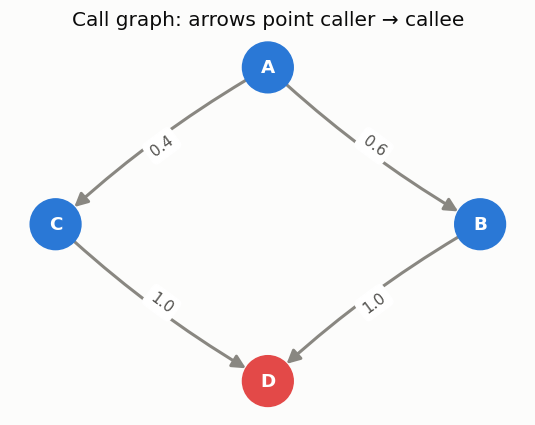

In [4]:
# Draw the dependency graph. D (the future root cause) is shown in red.
G = nx.DiGraph()
for i in range(N):
    for j in range(N):
        if W[i, j] > 0:
            G.add_edge(nodes[i], nodes[j], w=W[i, j])

pos = {"A": (0.5, 1.0), "B": (1.0, 0.5), "C": (0.0, 0.5), "D": (0.5, 0.0)}
colors = [RED if n == "D" else BLUE for n in G.nodes]

fig, ax = plt.subplots(figsize=(5, 4))
ax.grid(False)
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=1100, ax=ax)
nx.draw_networkx_labels(G, pos, font_color="white", font_weight="bold", ax=ax)
nx.draw_networkx_edges(G, pos, edge_color=GRAY, width=2, node_size=1100,
                       arrowsize=18, connectionstyle="arc3,rad=0.06", ax=ax)
nx.draw_networkx_edge_labels(
    G, pos, {(u, v): f"{d['w']:.1f}" for u, v, d in G.edges(data=True)},
    font_color=INK2, ax=ax)
ax.set_title("Call graph: arrows point caller → callee", color=INK)
ax.set_axis_off()
plt.tight_layout()
plt.show()

### 1.3 The resilience-damped matrix $M_R$ (Eq. 2)

The paper introduces one more modelling device. Real services have defences —
circuit breakers, timeouts, retries — so not every failure propagates. A
**resilience factor** $R_i \in [0, 1]$ is the probability that service $i$
*absorbs* a fault instead of passing it on. Damping each row by $(1 - R_i)$:

$$M_R = \mathrm{diag}(\mathbf{1} - \mathbf{R})\, W$$

With uniform $R = 0.1$, every row now sums to $0.9$ instead of $1$ — the matrix
is **sub-stochastic**: on every step, 10% of the walker's probability "leaks
away" (is absorbed).

> ⚠️ **Foreshadowing.** The paper's Proposition 3.1 (which we will verify
> numerically in Part 2) shows this uniform leak is *not* a new fault model at
> all — it is exactly equivalent to restarting the walk more often. Keep that
> in mind: it is one of the paper's main "myth-busting" points.

In [5]:
R_uniform = 0.1
M_R = np.diag((1 - R_uniform) * np.ones(N)) @ W

print("Row sums of M_R:", M_R.sum(axis=1).round(2), " <- 10% leaks per step")
pd.DataFrame(M_R, index=nodes, columns=nodes).round(2)

Row sums of M_R: [0.9 0.9 0.9 0. ]  <- 10% leaks per step


,A,B,C,D
A,0.0,0.54,0.36,0.0
B,0.0,0.00,0.00,0.9
C,0.0,0.00,0.00,0.9
D,0.0,0.00,0.00,0.0


## Interlude — Random Walk with Restart, from scratch

Every algorithm in this paper is a variation on one classical idea: the
**Random Walk with Restart (RWR)**. Before Part 2 points it at anomalies,
let's meet it on its own, with no incident in sight. The pure question RWR
answers is:

> *"Given the graph's structure, how close is every node to a chosen **seed**
> node — counting all paths, not just the shortest one?"*

### The walker

Drop a token on a seed node — say **A**, the frontend. At every tick it does
one of two things:

1. **Walk** — with probability $1-\alpha$, follow one outgoing edge at random,
   picking callee $j$ with probability $w_{ij}$. (Row $i$ of $W$ is exactly
   that probability distribution — this is why we made $W$ row-stochastic.)
2. **Restart** — with probability $\alpha$ (typically $0.15$), teleport back
   to the seed and start over. A node with no out-edges (our D) forces a
   restart: the walker has nowhere else to go.

The **RWR score** $r_i$ is simply the long-run fraction of ticks the walker
spends at node $i$.

### Why the restart is essential

Remove it and watch what happens on our graph: the walker slides down
A → B/C → D and is stuck at D **forever**. The long-run answer would be
"D: 100%" *regardless of the seed* — useless. The restart fixes two things at
once:

- **It makes the answer well-defined.** The walk can always get back to the
  seed, so a unique long-run distribution exists (no absorbing traps, no
  dependence on where you started counting).
- **It makes the answer *about the seed*.** Restarts keep the walker on a
  leash — it takes on average $1/\alpha$ steps before being yanked home. So
  nodes reachable from the seed by many short, heavy paths get visited often;
  remote nodes barely at all. $r$ is a *structure-aware proximity score*.

### The same walker, as a fixed point

Instead of one token, track the whole probability distribution $r^{(k)}$ of
where the walker is at tick $k$. One tick of bookkeeping is:

$$
r^{(k+1)} = \underbrace{(1-\alpha)\, P^{\top} r^{(k)}}_{\text{walkers that stepped along an edge}}
          \;+\; \underbrace{\alpha\, u}_{\text{walkers that teleported home}}
$$

where $u$ is the one-hot vector of the seed and $P$ is $W$ with the dangling
row (D) redirected to the seed. Iterating until $r$ stops changing is called
**power iteration**, and unrolling the recursion gives the sum-over-paths
view:

$$
r \;=\; \alpha \sum_{k=0}^{\infty} (1-\alpha)^k \, (P^{\top})^k\, u
$$

— node $i$'s score adds up *every* path from the seed to $i$, discounted by
$(1-\alpha)$ per hop. Short, heavy, numerous paths win.

**Name-dropping.** Restart into the *uniform* vector instead of a single seed
and this is Google's **PageRank**. Restart into any custom distribution and it
is **Personalized PageRank (PPR)** — which is just the graph-mining community's
name for RWR. Same engine, three names.

Two completely different ways to compute $r$ should now agree: *simulate* the
walker and count visits, or *iterate* the fixed-point equation. Let's do both.

In [6]:
# Give the walker its own random stream so the notebook's shared `rng`
# (used by the Part 4 experiment) is not disturbed.
walk_rng = np.random.default_rng(7)


def rwr_simulate(W, seed, alpha=0.15, n_steps=100_000, rng=walk_rng):
    '''Literally walk the graph: follow out-edges, restart to `seed` w.p. alpha.'''
    visits = np.zeros(W.shape[0])
    trail, node = [], seed
    for _ in range(n_steps):
        visits[node] += 1
        trail.append(node)
        if W[node].sum() == 0 or rng.random() < alpha:
            node = seed                             # restart (forced at dangling D)
        else:
            node = rng.choice(len(W), p=W[node])    # walk one edge
    return visits / visits.sum(), trail


SEED = 0   # restart target: A, the frontend
r_sim, trail = rwr_simulate(W, SEED)

print("First 24 ticks:", " → ".join(nodes[i] for i in trail[:24]))
print("\nEvery 'A' right after a 'D' is a restart — D is dangling, so each visit")
print("bounces the walker home; elsewhere restarts fire ~15% of the time.")
print("\nFraction of time at each node:", dict(zip(nodes, r_sim.round(3))))

First 24 ticks: A → C → D → A → C → A → C → D → A → B → D → A → C → D → A → B → D → A → A → A → B → D → A → B

Every 'A' right after a 'D' is a restart — D is dangling, so each visit
bounces the walker home; elsewhere restarts fire ~15% of the time.

Fraction of time at each node: {'A': np.float64(0.388), 'B': np.float64(0.199), 'C': np.float64(0.132), 'D': np.float64(0.281)}


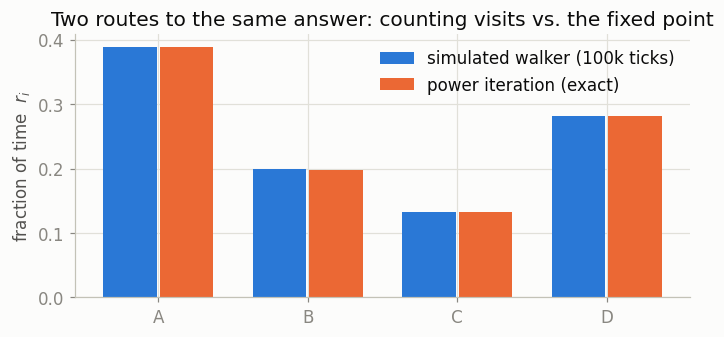

   simulated   exact
A     0.3882  0.3887
B     0.1989  0.1983
C     0.1319  0.1322
D     0.2811  0.2809

Max |difference| = 0.0006 -> pure Monte-Carlo noise.
Reading the scores: A is the seed, so it dominates. D beats B and C
even though it is two hops away, because BOTH branches funnel into it —
RWR rewards nodes that many short, heavy paths lead to. Remember that.


In [7]:
def rwr_exact(W, seed, alpha=0.15, eps=1e-12, max_iter=10_000):
    '''Power iteration for the RWR fixed point  r = (1-α) P^T r + α u.'''
    u = np.zeros(W.shape[0])
    u[seed] = 1.0
    P = W.copy()
    P[W.sum(axis=1) == 0] = u          # dangling rows restart with certainty
    r = u.copy()
    for _ in range(max_iter):
        r_new = (1 - alpha) * P.T @ r + alpha * u
        if np.abs(r_new - r).sum() < eps:
            break
        r = r_new
    return r


r_exact = rwr_exact(W, SEED)

fig, ax = plt.subplots(figsize=(6.5, 3.2))
x = np.arange(N)
width = 0.38
ax.bar(x - width / 2, r_sim, width=width * 0.94, color=BLUE,
       label="simulated walker (100k ticks)")
ax.bar(x + width / 2, r_exact, width=width * 0.94, color=ORANGE,
       label="power iteration (exact)")
ax.set_xticks(x, nodes)
ax.set_ylabel("fraction of time  $r_i$")
ax.set_title("Two routes to the same answer: counting visits vs. the fixed point",
             color=INK)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(pd.DataFrame({"simulated": r_sim, "exact": r_exact}, index=nodes).round(4))
print(f"\nMax |difference| = {np.abs(r_sim - r_exact).max():.4f}",
      "-> pure Monte-Carlo noise.")
print("Reading the scores: A is the seed, so it dominates. D beats B and C")
print("even though it is two hops away, because BOTH branches funnel into it —")
print("RWR rewards nodes that many short, heavy paths lead to. Remember that.")

### The one knob: what $\alpha$ actually controls

The number of walk steps between restarts is geometric with mean $1/\alpha$,
so $\alpha$ is literally the length of the walker's leash. Crank it up and the
scores collapse onto the seed (the walk contributes nothing); drop it toward 0
and the seed is forgotten (on our graph, everything drains into the sink D).

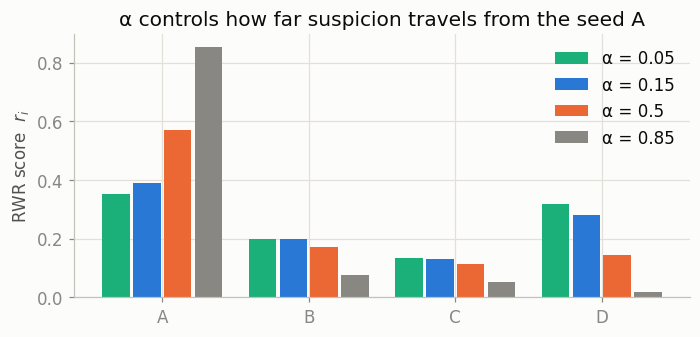

α = 0.85 -> leash of ~1.2 hops: the walker barely leaves the seed.
α = 0.05 -> ~20-hop excursions: mass drifts to the graph's sink D.
α = 0.15 (the default everywhere below) keeps a useful middle ground:
scores reflect the seed AND the structure around it.


In [8]:
# The restart probability is a leash: mean walk length before a restart
# is 1/alpha hops (the segment length is geometric).
fig, ax = plt.subplots(figsize=(6.5, 3.2))
x = np.arange(N)
width = 0.21
for k, (a_val, c) in enumerate(zip([0.05, 0.15, 0.5, 0.85],
                                   [AQUA, BLUE, ORANGE, GRAY])):
    ax.bar(x + (k - 1.5) * width, rwr_exact(W, SEED, alpha=a_val),
           width=width * 0.9, color=c, label=f"α = {a_val}")
ax.set_xticks(x, nodes)
ax.set_ylabel("RWR score  $r_i$")
ax.set_title("α controls how far suspicion travels from the seed A", color=INK)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print("α = 0.85 -> leash of ~1.2 hops: the walker barely leaves the seed.")
print("α = 0.05 -> ~20-hop excursions: mass drifts to the graph's sink D.")
print("α = 0.15 (the default everywhere below) keeps a useful middle ground:")
print("scores reflect the seed AND the structure around it.")

### From RWR to Part 2's IRWR: three substitutions

You now own the whole engine. Part 2 is *exactly* this algorithm with three
substitutions, each of which will matter:

1. **Restart target.** The one-hot seed $u$ becomes the **anomaly vector**
   $s_{\text{obs}}$: instead of one detective HQ, restart mass is spread over
   every symptomatic service in proportion to how sick it looks. (RWR with a
   general restart distribution is precisely Personalized PageRank.)
2. **Transition matrix.** $W$ becomes the resilience-damped $M_R$, which leaks
   10% of probability per step. Proposition 3.1 will expose this as a bigger
   $\alpha$ in disguise.
3. **Flow direction.** The paper iterates $r \leftarrow (1-\alpha) M_R\, r +
   \alpha\, s_{\text{obs}}$ — note $M_R\, r$, **not** $M_R^\top r$. With a
   row-stochastic matrix, $(M r)_i = \sum_j M_{ij} r_j$ means node $i$
   *collects* score from its callees, so suspicion flows **callee → caller** —
   the reverse of the walker we just simulated, whose mass moved caller →
   callee via $P^\top r$.

The convergence guarantee survives all three substitutions: any update of the
form $r \leftarrow (1-\alpha) M r + \alpha v$ with (sub-)stochastic $M$ is a
contraction, so a unique fixed point always exists. What is *not* guaranteed —
as Part 2 is about to demonstrate — is that the fixed point points at the
right service.

## Part 2 — Basic IRWR (§3.3)

### 2.1 The incident: D fails, but B screams loudest

Now the database **D** develops a fault. Failures cascade **backward** through
the call graph: B and C (which call D) start timing out, then A inherits weaker
symptoms. The monitoring system hands us an **anomaly vector** $s_{\text{obs}}$
— one non-negative score per service, normalised to sum to 1.

We use the moderate-visibility vector from Figure 2 of the paper ($v = 0.3$):
the root cause D is *partially* visible, but the victim B is still the loudest.

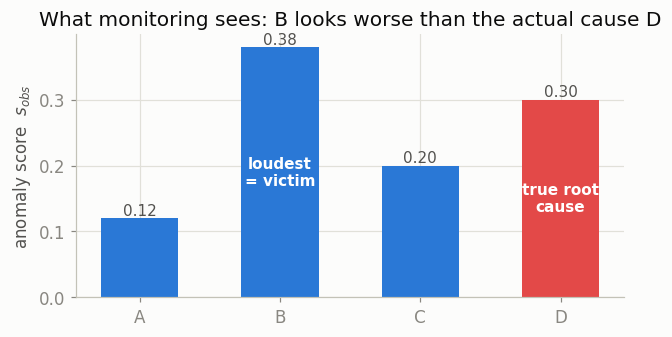

Naive answer (sort by anomaly): ['B', 'D', 'C', 'A']  -> blames B. Wrong!


In [9]:
# Anomaly vector at moderate root-cause visibility (v = 0.3, Fig. 2)
s_obs = np.array([0.12, 0.38, 0.20, 0.30])
s_obs = s_obs / s_obs.sum()
ROOT = 3   # index of D, the true root cause

fig, ax = plt.subplots(figsize=(6, 3.2))
bar_colors = [RED if i == ROOT else BLUE for i in range(N)]
bars = ax.bar(nodes, s_obs, color=bar_colors, width=0.55)
for b, v in zip(bars, s_obs):
    ax.annotate(f"{v:.2f}", (b.get_x() + b.get_width() / 2, v),
                ha="center", va="bottom", color=INK2, fontsize=10)
ax.text(1, s_obs[1] / 2, "loudest\n= victim", ha="center", va="center",
        color="white", fontsize=10, fontweight="bold")
ax.text(3, s_obs[3] / 2, "true root\ncause", ha="center", va="center",
        color="white", fontsize=10, fontweight="bold")
ax.set_ylabel("anomaly score  $s_{obs}$")
ax.set_title("What monitoring sees: B looks worse than the actual cause D",
             color=INK)
plt.tight_layout()
plt.show()

print("Naive answer (sort by anomaly):",
      [nodes[i] for i in np.argsort(-s_obs)], " -> blames B. Wrong!")

### 2.2 Intuition: a detective who keeps returning to the evidence

A **Random Walk with Restart (RWR)** works like a detective wandering the graph:

1. **Walk** — from the current service, follow the call structure to gather
   how suspicion flows between neighbours.
2. **Restart** — with probability $\alpha$ (e.g. 0.15), teleport back to the
   *evidence*: a service chosen according to the anomaly vector.

Repeat forever. The long-run fraction of time spent at each node is the
**suspicion score** $r$. The restart keeps the detective anchored to the
observed symptoms; the walk lets structural context redistribute suspicion.

Formally, IRWR iterates (Eq. 3 in the paper):

$$
r^{(k+1)} = \underbrace{(1-\alpha)\, M_R\, r^{(k)}}_{\text{spread along the graph}}
          \; + \; \underbrace{\alpha\, s_{\text{obs}}}_{\text{re-inject the evidence}}
$$

starting from $r^{(0)} = s_{\text{obs}}$, until $r$ stops changing.

One important reading detail: with a row-stochastic $W$, the product
$(M_R\, r)_i = \sum_j M_{ij}\, r_j$ means node $i$ collects score from its
**callees** — suspicion flows from callees *up into their callers*. Setting
$R = 0$ recovers exactly the Personalized PageRank (PPR) used by MicroRCA.

Because $\alpha > 0$, the update is a *contraction*: each iteration shrinks the
distance to the fixed point by at least $(1-\alpha)$, so convergence is
guaranteed — typically in a few dozen iterations.

Converged in 4 iterations
(Our toy graph has no cycles and only 3 levels, so the walk settles
 almost instantly. On real graphs with cycles, expect 15-50 iterations,
 each shrinking the remaining error by a factor of about (1-α).)


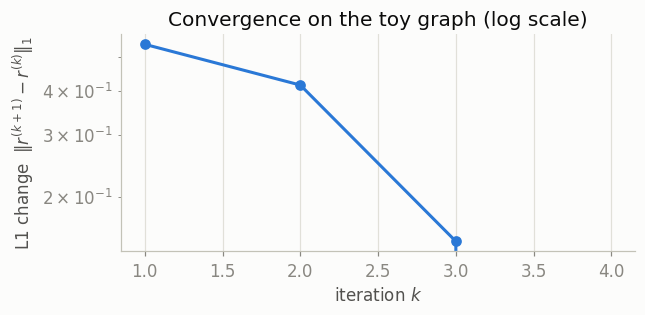

In [10]:
def irwr(M, s_obs, alpha=0.15, eps=1e-10, max_iter=1000):
    '''Basic IRWR / PPR power iteration (Eq. 3). Returns scores + error history.'''
    r = s_obs.copy()
    errors = []
    for k in range(max_iter):
        r_new = (1 - alpha) * M @ r + alpha * s_obs
        errors.append(np.abs(r_new - r).sum())   # L1 change
        r = r_new
        if errors[-1] < eps:
            break
    return r, errors


r_basic, errs = irwr(M_R, s_obs)
print(f"Converged in {len(errs)} iterations")
print("(Our toy graph has no cycles and only 3 levels, so the walk settles")
print(" almost instantly. On real graphs with cycles, expect 15-50 iterations,")
print(" each shrinking the remaining error by a factor of about (1-α).)")

fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogy(range(1, len(errs) + 1), errs, "-o", color=BLUE, lw=2)
ax.set_xlabel("iteration $k$")
ax.set_ylabel(r"L1 change  $\|r^{(k+1)}-r^{(k)}\|_1$")
ax.set_title("Convergence on the toy graph (log scale)", color=INK)
plt.tight_layout()
plt.show()

Basic IRWR scores : {'A': np.float64(0.0797), 'B': np.float64(0.0914), 'C': np.float64(0.0644), 'D': np.float64(0.045)}
Basic IRWR ranking: ['B', 'A', 'C', 'D']


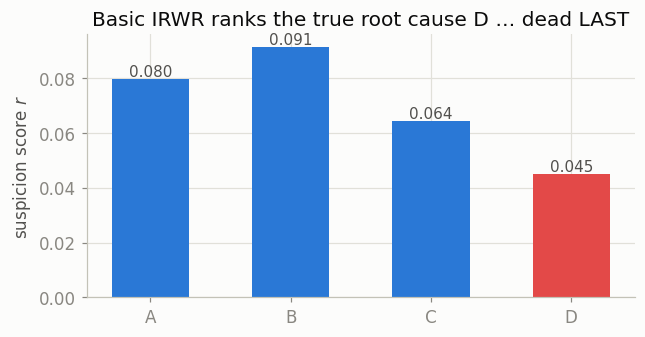

In [11]:
ranking = np.argsort(-r_basic)
print("Basic IRWR scores :", dict(zip(nodes, r_basic.round(4))))
print("Basic IRWR ranking:", [nodes[i] for i in ranking])

fig, ax = plt.subplots(figsize=(6, 3.2))
bars = ax.bar(nodes, r_basic, color=[RED if i == ROOT else BLUE
                                     for i in range(N)], width=0.55)
for b, v in zip(bars, r_basic):
    ax.annotate(f"{v:.3f}", (b.get_x() + b.get_width() / 2, v),
                ha="center", va="bottom", color=INK2, fontsize=10)
ax.set_ylabel("suspicion score $r$")
ax.set_title("Basic IRWR ranks the true root cause D … dead LAST", color=INK)
plt.tight_layout()
plt.show()

### 2.3 What just went wrong?

Basic IRWR ranked the victim **B first and the true cause D last** — even worse
than naively sorting the anomaly vector. Two effects conspire:

1. **The restart is dominated by victims.** Every iteration re-injects
   $\alpha \, s_{\text{obs}}$, and $s_{\text{obs}}$ is loudest at B. The walk is
   repeatedly told *"the evidence points at B"*.
2. **The walk drains D's mass upstream.** $(M_R r)_i$ moves score from callees
   into callers, and D has **no out-edges** in $M_R$'s row — so D receives
   nothing from the walk and keeps only its restart share $\alpha \, s_D$.
   Everything D had flows up to B, C, and eventually A.

This is exactly the failure mode the paper attacks: the raw anomaly vector is
the wrong thing to restart into, and the plain transition matrix gives the true
source nowhere to *accumulate* suspicion. Hold that thought for Part 3.

### 2.4 Proposition 3.1 — resilience damping is just a higher restart rate

Before adding enhancements, the paper clears up a myth. Recall $M_R$ leaks 10%
of probability per step. Where does leaked probability effectively go? It is
exactly compensated by the restart term. The proposition says: IRWR with
restart $\alpha$ and uniform resilience $R$ produces the **same ranking** as
plain PPR (no damping) with a boosted restart

$$\alpha_{\text{eff}} = 1 - (1-\alpha)(1-R) = \alpha + R - \alpha R .$$

For the defaults $\alpha = 0.15$, $R = 0.1$: $\alpha_{\text{eff}} = 0.235$.
The two score vectors should agree up to one constant scale factor
($\alpha / \alpha_{\text{eff}}$) — i.e. identical rankings. Let's check:

In [12]:
alpha, R = 0.15, 0.1
alpha_eff = 1 - (1 - alpha) * (1 - R)
print(f"alpha_eff = 1 - (1-{alpha})(1-{R}) = {alpha_eff:.3f}")

r_damped, _ = irwr(M_R, s_obs, alpha=alpha)       # damped walk on M_R
r_tuned, _  = irwr(W,   s_obs, alpha=alpha_eff)   # plain PPR, boosted restart

comparison = pd.DataFrame({
    "IRWR on M_R (α=0.15, R=0.1)": r_damped,
    "PPR on W (α=0.235)": r_tuned,
    "ratio": r_damped / r_tuned,
}, index=nodes)
print(comparison.round(4))
print(f"\nRatio is constant ≈ α/α_eff = {alpha/alpha_eff:.4f} -> same ranking.")
print("Lesson: uniform 'resilience damping' adds NO new information;")
print("it silently tunes the restart rate. So any fair comparison must use")
print("a restart-TUNED PPR as the baseline — which is what the paper does.")

alpha_eff = 1 - (1-0.15)(1-0.1) = 0.235
   IRWR on M_R (α=0.15, R=0.1)  PPR on W (α=0.235)   ratio
A                       0.0797              0.1248  0.6383
B                       0.0914              0.1432  0.6383
C                       0.0644              0.1009  0.6383
D                       0.0450              0.0705  0.6383

Ratio is constant ≈ α/α_eff = 0.6383 -> same ranking.
Lesson: uniform 'resilience damping' adds NO new information;
it silently tunes the restart rate. So any fair comparison must use
a restart-TUNED PPR as the baseline — which is what the paper does.


## Part 3 — Enhanced IRWR: eIRWR (§3.4–3.5)

Basic IRWR failed because of *where it restarts* and *where probability can
accumulate*. eIRWR fixes both with three mechanisms plus an outer loop:

| # | Mechanism | Paper | One-line intuition |
|---|---|---|---|
| 1 | Anomaly-conditioned resilience | §3.4.1, Eq. 4–5 | Distressed services have strained defences → they propagate faults more |
| 2 | Backward edges + self-loops | §3.4.2, Eq. 6–8 | Let suspicion flow back down to the source, and let the source *hold on* to it |
| 3 | Power-law teleportation sharpening | §3.4.3, Eq. 9–10 | Restart at the few *most* suspicious nodes, not proportionally everywhere |
| 4 | Belief refinement (outer loop) | §3.5, Eq. 11 | Re-run with a belief nudged by the previous answer — gently |

We build each one on our toy example, then assemble the full algorithm.

### 3.1 Anomaly-conditioned resilience (Eq. 4)

In Part 1 resilience was one uniform constant — and Prop. 3.1 showed that's
vacuous. eIRWR instead ties each service's resilience to its *own* anomaly:

$$R_i = R_{\text{base}} \cdot e^{-\beta \hat{s}_i},
\qquad \hat{s}_i = s_i / \max_j s_j$$

A healthy service ($\hat{s}_i \approx 0$) keeps its full resilience
$R_{\text{base}}$. A distressed one ($\hat{s}_i \approx 1$) has its circuit
breakers and retry budgets exhausted — resilience decays exponentially, so it
passes faults along more readily. $\beta$ controls how sharply.

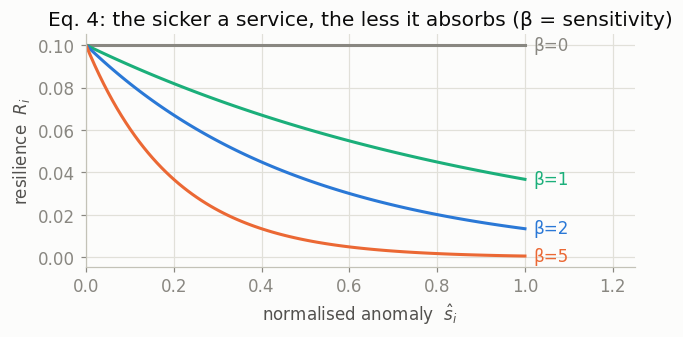

   anomaly ŝ  resilience R_i
A      0.316           0.053
B      1.000           0.014
C      0.526           0.035
D      0.789           0.021


In [13]:
R_base, beta = 0.1, 2.0

s_grid = np.linspace(0, 1, 100)
fig, ax = plt.subplots(figsize=(6, 3.2))
for b_val, c in zip([0.0, 1.0, 2.0, 5.0], [GRAY, AQUA, BLUE, ORANGE]):
    ax.plot(s_grid, R_base * np.exp(-b_val * s_grid), color=c, lw=2)
    ax.annotate(f"β={b_val:g}", (1.0, R_base * np.exp(-b_val)),
                xytext=(1.02, R_base * np.exp(-b_val)), color=c, va="center")
ax.set_xlabel(r"normalised anomaly  $\hat{s}_i$")
ax.set_ylabel(r"resilience  $R_i$")
ax.set_xlim(0, 1.25)
ax.set_title("Eq. 4: the sicker a service, the less it absorbs (β = sensitivity)",
             color=INK)
plt.tight_layout()
plt.show()

# Applied to our incident:
s_hat = s_obs / s_obs.max()
R_adaptive = R_base * np.exp(-beta * s_hat)
print(pd.DataFrame({"anomaly ŝ": s_hat, "resilience R_i": R_adaptive},
                   index=nodes).round(3))
M_base = np.diag(1 - R_adaptive) @ W        # Eq. 5

(Honest footnote: the paper's ablation §4.3 finds this mechanism contributes
little on its own — the heavy lifting is done by the next two. It is kept
because it is cheap and physically sensible.)

### 3.2 Backward edges and self-loops (Eq. 6–8)

This is the structural fix for the "D can never accumulate" problem.

**Backward edges (Eq. 6).** For every forward edge $v_i \to v_j$ that has no
reverse edge, add a weak reverse transition with weight $\rho \cdot C_i$
(where $C$ is the current normalised belief and $\rho = 0.3$ a discount).
In our walk convention, an entry in row $j$ pointing at $i$ lets the **callee
$j$ pull suspicion back from its caller $i$**. Now D — everyone's callee — can
finally receive the suspicion its victims collected.

**Self-loops (Eq. 7).** A root cause has a signature: it is *more* anomalous
than the services around it (it is the source, not an echo). Nodes whose belief
exceeds their strongest outgoing transition get a self-loop:

$$A_{\text{self}}[i,i] = \max\!\Big(0,\; C_i - \max_{j \in \mathcal{N}(i)} M_{ij}\Big)$$

A self-loop lets a suspicious node **keep** probability instead of leaking it
all away — the walker "lingers" at likely root causes.

**Combine and renormalise (Eq. 8):**

$$M = \mathrm{RowNorm}\big(M_{\text{base}} \cdot \mathrm{diag}(C) + A_{\text{bwd}} + A_{\text{self}}\big)$$

In [14]:
rho = 0.3
A = (W > 0).astype(float)          # binary adjacency (forward edges)

# Use the observation as the initial belief (the outer loop will refine it)
C = s_obs / s_obs.max()

M_aug = M_base @ np.diag(C)        # forward transitions, scaled by belief

# Backward edges (Eq. 6): entry [j, i] = rho * C_i for forward edge (i, j)
A_bwd = rho * (C[:, None] * A).T   # transpose puts the entry at [callee, caller]
A_bwd[A > 0] = 0.0                 # only where no forward edge already exists
M_aug = M_aug + A_bwd

# Self-loops (Eq. 7): only for nodes whose belief beats their max out-weight
self_loops = np.maximum(0.0, C - M_aug.max(axis=1))
M_aug = M_aug + np.diag(self_loops)
print("Self-loop weights:", dict(zip(nodes, self_loops.round(3))))
print("B qualifies too (it is the loudest), but D's self-loop is twice as")
print("strong — and B's huge forward edge to D leaks most of B's mass anyway.")

# Row-normalise (Eq. 8)
row = M_aug.sum(axis=1)
M_aug = M_aug / np.where(row == 0, 1.0, row)[:, None]

print("\nAugmented transition matrix M (row-normalised):")
print(pd.DataFrame(M_aug, index=nodes, columns=nodes).round(2))
print("\nRead row D: D now pulls suspicion from B and C (backward edges)")
print("AND keeps a big share for itself (self-loop). D can finally accumulate.")

Self-loop weights: {'A': np.float64(0.0), 'B': np.float64(0.221), 'C': np.float64(0.0), 'D': np.float64(0.489)}
B qualifies too (it is the loudest), but D's self-loop is twice as
strong — and B's huge forward edge to D leaks most of B's mass anyway.

Augmented transition matrix M (row-normalised):
      A     B     C     D
A  0.00  0.74  0.26  0.00
B  0.09  0.20  0.00  0.71
C  0.11  0.00  0.00  0.89
D  0.00  0.32  0.17  0.52

Read row D: D now pulls suspicion from B and C (backward edges)
AND keeps a big share for itself (self-loop). D can finally accumulate.


### 3.3 Power-law teleportation sharpening (Eq. 9–10)

The second half of the fix: stop restarting into the *raw* anomaly vector.
Raise the belief to a power $q$ and renormalise:

$$v = \frac{b^{\,q}}{\|b^{\,q}\|_1}, \qquad q \ge 1$$

Squaring (or worse) **exaggerates gaps**: big entries grow relative to small
ones, so restart mass concentrates on the few most suspicious nodes and the
background noise is suppressed. $q = 1$ is the ordinary restart.

**Adaptive exponent (Eq. 10).** Sharpening a weak, noisy signal would amplify
noise. So eIRWR measures signal quality $\sigma = b_{\max} / \bar{b}$
(peak-to-mean ratio) and interpolates: no sharpening when $\sigma < 5$,
full $q$ when $\sigma > 20$.

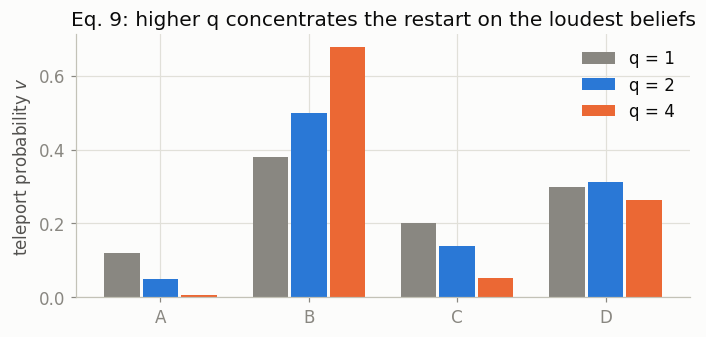

Our toy signal quality: sigma = 1.5 (< 5) -> adaptive q stays at 1.
On a real 12,000-node graph a genuine incident easily reaches sigma > 20,
because thousands of healthy services drag the mean down.


In [15]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))
x = np.arange(N)
width = 0.26
for k, (q_val, c) in enumerate(zip([1, 2, 4], [GRAY, BLUE, ORANGE])):
    v = s_obs ** q_val
    v = v / v.sum()
    ax.bar(x + (k - 1) * width, v, width=width * 0.92, color=c,
           label=f"q = {q_val}")
ax.set_xticks(x, nodes)
ax.set_ylabel("teleport probability $v$")
ax.set_title("Eq. 9: higher q concentrates the restart on the loudest beliefs",
             color=INK)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

sigma = s_obs.max() / s_obs.mean()
print(f"Our toy signal quality: sigma = {sigma:.1f} (< 5) -> adaptive q stays at 1.")
print("On a real 12,000-node graph a genuine incident easily reaches sigma > 20,")
print("because thousands of healthy services drag the mean down.")

### 3.4 Belief refinement — the outer loop (Eq. 11)

Which vector should we sharpen and build $M$ from? At the start, all we have is
$s_{\text{obs}}$. But after one full walk we hold something better: the
converged suspicion $r$. eIRWR therefore wraps everything in an outer loop that
blends the two into a **belief**:

$$b^{(t)} = (1-\mu)\, s_{\text{obs}} + \mu\, r^{(t-1)}, \qquad \mu = 0.1$$

and rebuilds $M$ and $v$ from $b$ before walking again.

**Why so timid ($\mu = 0.1$)?** Confirmation bias. If the walk fed its own
output straight back in, an early wrong guess would reinforce itself. Keeping
the belief 90% anchored to the raw observation lets structure *nudge* the
evidence without overruling it. In practice a single outer pass
($n_{\text{outer}} = 1$) is usually enough.

### 3.5 Putting it together — the full eIRWR (Algorithm 1)

In [16]:
def power_iteration(M, v, r0, alpha=0.15, eps=1e-10, max_iter=2000):
    '''Inner loop of Algorithm 1: RWR on M restarting into v, warm start r0.'''
    r = r0.copy()
    for _ in range(max_iter):
        r_new = (1 - alpha) * M @ r + alpha * v
        if np.abs(r_new - r).sum() < eps:
            break
        r = r_new
    return r


def eirwr(W, s_obs, R_base=0.1, beta=2.0, alpha=0.15, rho=0.3,
          q=2.0, mu=0.1, n_outer=1):
    '''Enhanced IRWR (Algorithm 1), in plain NumPy. Paper defaults throughout.'''
    N = len(s_obs)
    A = (W > 0).astype(float)

    # -- Mechanism 1: anomaly-conditioned resilience (Eq. 4-5) --------------
    s_hat = s_obs / s_obs.max()
    R = R_base * np.exp(-beta * s_hat)
    M_base = np.diag(1 - R) @ W

    r = s_obs.copy()                                   # initial belief
    for t in range(n_outer):
        # -- Mechanism 4: belief refinement (Eq. 11) ------------------------
        b = (1 - mu) * s_obs + mu * r
        C = b / b.max()

        # -- Mechanism 2: backward edges + self-loops (Eq. 6-8) -------------
        M = M_base @ np.diag(C)                        # belief-scaled forward
        A_bwd = rho * (C[:, None] * A).T               # Eq. 6 at [callee,caller]
        A_bwd[A > 0] = 0.0                             # skip existing edges
        M = M + A_bwd
        M = M + np.diag(np.maximum(0.0, C - M.max(axis=1)))   # Eq. 7
        row = M.sum(axis=1)
        M = M / np.where(row == 0, 1.0, row)[:, None]  # Eq. 8 RowNorm

        # -- Mechanism 3: sharpened teleportation (Eq. 9-10) ----------------
        sigma = b.max() / b.mean()
        q_eff = 1 + (q - 1) * min(1.0, max(0.0, (sigma - 5) / 15))
        v = b ** q_eff
        v = v / v.sum()

        # -- inner power iteration (same engine as basic IRWR) --------------
        r = power_iteration(M, v, r, alpha=alpha)
    return r


r_enhanced = eirwr(W, s_obs)
print("eIRWR scores :", dict(zip(nodes, r_enhanced.round(3))))
print("eIRWR ranking:", [nodes[i] for i in np.argsort(-r_enhanced)])
print("\nD climbs from LAST (basic IRWR) to 2nd — with the root cause only")
print("30% visible and a graph of just 4 nodes to work with.")

eIRWR scores : {'A': np.float64(0.28), 'B': np.float64(0.316), 'C': np.float64(0.286), 'D': np.float64(0.304)}
eIRWR ranking: ['B', 'D', 'C', 'A']

D climbs from LAST (basic IRWR) to 2nd — with the root cause only
30% visible and a graph of just 4 nodes to work with.


### 3.6 Raise the visibility, and eIRWR nails it

The paper's headline results are at moderate-to-high visibility (MRR 0.75 at
$v{=}0.3$, 0.94 at $v{=}0.5$). Let's replay the same incident with the
$v = 0.5$ anomaly vector from Figure 2 — the root cause D is now genuinely the
loudest signal. Surely basic IRWR gets it now…?

anomaly ranking : ['D', 'B', 'C', 'A'] (D loudest)
basic IRWR      : ['B', 'A', 'C', 'D'] <- STILL last!
eIRWR           : ['D', 'B', 'C', 'A'] <- correct


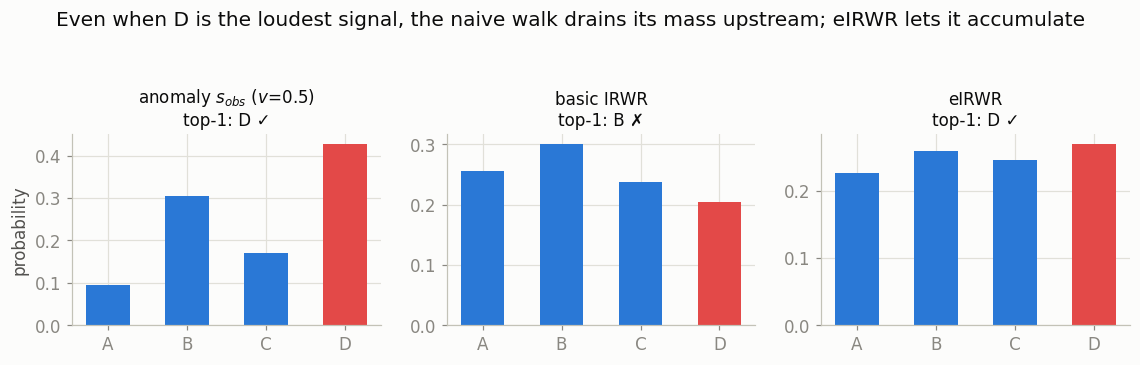

In [17]:
s_v5 = np.array([0.10, 0.32, 0.18, 0.45])   # Fig. 2, v = 0.5 column
s_v5 = s_v5 / s_v5.sum()

r_b5, _ = irwr(M_R, s_v5)
r_e5 = eirwr(W, s_v5)

print("anomaly ranking :", [nodes[i] for i in np.argsort(-s_v5)], "(D loudest)")
print("basic IRWR      :", [nodes[i] for i in np.argsort(-r_b5)], "<- STILL last!")
print("eIRWR           :", [nodes[i] for i in np.argsort(-r_e5)], "<- correct")

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.1), sharey=False)
for ax, (title, vals) in zip(axes, [
        ("anomaly $s_{obs}$ ($v$=0.5)", s_v5),
        ("basic IRWR", r_b5 / r_b5.sum()),
        ("eIRWR", r_e5 / r_e5.sum())]):
    ax.bar(nodes, vals, color=[RED if i == ROOT else BLUE for i in range(N)],
           width=0.55)
    top = int(np.argmax(vals))
    ax.set_title(f"{title}\ntop-1: {nodes[top]} "
                 f"{'✓' if top == ROOT else '✗'}", color=INK, fontsize=11)
axes[0].set_ylabel("probability")
fig.suptitle("Even when D is the loudest signal, the naive walk drains its mass "
             "upstream; eIRWR lets it accumulate", color=INK, y=1.06)
plt.tight_layout()
plt.show()

**Why basic IRWR still fails here:** the walk direction moves *all* of D's mass
to its callers on every step, and D's only income is the restart. eIRWR wins
because of the structure we added — look again at row D of the augmented matrix
in §3.2: a self-loop to *hold* mass and backward edges to *pull* it back from
the victims. Sharpening then aims the restarts at D-like nodes instead of
spraying them across every noisy service.

That is the paper's core claim in miniature: **the gains come from reshaping
the restart and the accumulation structure — not from a new "fault propagation"
transition matrix** (which Prop. 3.1 showed was an illusion anyway).

## Part 4 — A mini version of the paper's experiment

Four nodes make a good chalkboard, but the paper evaluates on 12K–25K-node
Alibaba topologies with simulated incidents (§4.1). Let's reproduce that recipe
at small scale:

1. build a random 60-service call graph,
2. pick a random *callee* as root cause,
3. propagate its fault **backward** to callers with geometric decay
   ($\gamma = 0.6$, 5 hops) plus Gaussian noise — exactly the paper's simulator,
4. mix in the root cause's own signal according to a visibility $v$,
5. score each method by **Mean Reciprocal Rank** — MRR $= \mathbb{E}[1/\text{rank of true root cause}]$
   (1.0 = always ranked first; 0.5 = typically 2nd).

We compare plain PPR (MicroRCA), the restart-tuned PPR that Prop. 3.1 demands
as the fair baseline, and eIRWR — 100 incidents per visibility level.

In [18]:
# 1. Random layered call graph: each service calls a few higher-index services,
#    so low-index nodes are "frontends" and high-index nodes are deep backends.
N_big = 60
lam_big = np.zeros((N_big, N_big))
for i in range(N_big - 1):
    n_out = int(rng.integers(1, 4))
    callees = rng.choice(np.arange(i + 1, N_big),
                         size=min(n_out, N_big - 1 - i), replace=False)
    for j in callees:
        lam_big[i, j] = rng.integers(10, 500)

row = lam_big.sum(axis=1, keepdims=True)
W_big = np.divide(lam_big, row, out=np.zeros_like(lam_big), where=row > 0)
M_R_big = 0.9 * W_big  # uniform damping, R = 0.1
print(f"Graph: {N_big} nodes, {int((lam_big > 0).sum())} edges")


def simulate_incident(root, v, gamma=0.6, hops=5, noise=0.05):
    '''Paper's simulator (§4.1): backward cascade with geometric decay.'''
    s = np.zeros(N_big)
    s[root] = v                                   # root's own visibility
    frontier = {root: 1.0}
    for _ in range(hops):
        nxt = {}
        for node, sig in frontier.items():
            for caller in np.where(lam_big[:, node] > 0)[0]:
                nxt[caller] = max(nxt.get(caller, 0.0), sig * gamma)
        for caller, sig in nxt.items():           # victims inherit the cascade
            s[caller] = max(s[caller], sig * (1 - v) if v > 0 else sig)
        frontier = nxt
    s += np.abs(rng.normal(0, noise, N_big))      # measurement noise
    return s / s.sum()

Graph: 60 nodes, 111 edges


In [19]:
# 2. Run 100 incidents per visibility level for each method.
callees = [j for j in range(N_big) if lam_big[:, j].sum() > 0]
visibilities = [0.1, 0.3, 0.5]
methods = {
    "PPR (MicroRCA)":      lambda s: irwr(W_big, s, alpha=0.15)[0],
    "PPR, tuned α=0.235":  lambda s: irwr(W_big, s, alpha=0.235)[0],
    "eIRWR":               lambda s: eirwr(W_big, s),
}

mrr = {name: [] for name in methods}
for v in visibilities:
    recip = {name: [] for name in methods}
    for _ in range(100):
        root = int(rng.choice(callees))
        s = simulate_incident(root, v)
        for name, fn in methods.items():
            scores = fn(s)
            rank = int(np.where(np.argsort(-scores) == root)[0][0]) + 1
            recip[name].append(1.0 / rank)
    for name in methods:
        mrr[name].append(np.mean(recip[name]))

results = pd.DataFrame(mrr, index=[f"v = {v}" for v in visibilities]).T
print(results.round(3))

                    v = 0.1  v = 0.3  v = 0.5
PPR (MicroRCA)        0.168    0.238    0.434
PPR, tuned α=0.235    0.177    0.240    0.509
eIRWR                 0.233    0.309    0.995


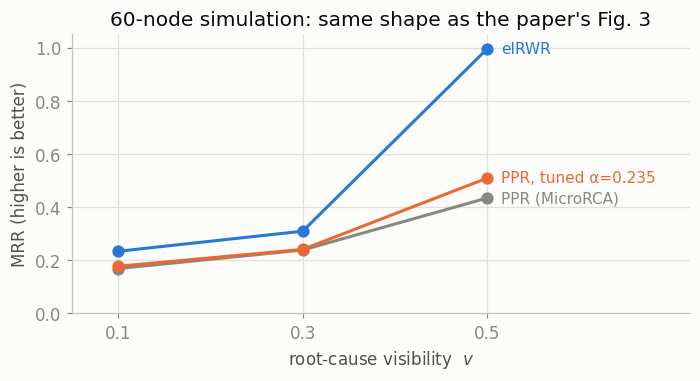

Same qualitative story as Table 3/4 of the paper:
 • tuning the restart helps PPR a little (the Prop. 3.1 effect),
 • eIRWR's restart shaping delivers the real jump,
 • and the gap widens as the root cause becomes more visible.


In [20]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
for name, c in zip(methods, [GRAY, ORANGE, BLUE]):
    ax.plot(visibilities, mrr[name], "-o", color=c, lw=2, markersize=7)
    ax.annotate(name, (visibilities[-1], mrr[name][-1]),
                xytext=(0.515, mrr[name][-1]), color=c, va="center", fontsize=10)
ax.set_xlabel("root-cause visibility  $v$")
ax.set_ylabel("MRR (higher is better)")
ax.set_xlim(0.05, 0.72)
ax.set_ylim(0, 1.05)
ax.set_xticks(visibilities)
ax.set_title("60-node simulation: same shape as the paper's Fig. 3", color=INK)
plt.tight_layout()
plt.show()

print("Same qualitative story as Table 3/4 of the paper:")
print(" • tuning the restart helps PPR a little (the Prop. 3.1 effect),")
print(" • eIRWR's restart shaping delivers the real jump,")
print(" • and the gap widens as the root cause becomes more visible.")

## Recap — the whole method on one page

| Symbol | Meaning | Where |
|---|---|---|
| $W$ | Row-stochastic call-frequency matrix: $w_{ij}$ = share of $i$'s traffic going to $j$ | Eq. 1 |
| $M_R = \mathrm{diag}(1-R)\,W$ | Resilience-damped transitions (careful: uniform $R$ ⇒ just a higher restart, Prop. 3.1) | Eq. 2 |
| $r \leftarrow (1-\alpha) M r + \alpha v$ | The RWR engine: spread suspicion + re-inject evidence | Eq. 3 |
| $R_i = R_{\text{base}} e^{-\beta \hat{s}_i}$ | Sick services propagate faults more readily | Eq. 4 |
| $A_{\text{bwd}},\ A_{\text{self}}$ | Backward edges pull suspicion to the source; self-loops let it *stay* there | Eq. 6–7 |
| $v = b^q / \|b^q\|_1$ | Sharpened restart: concentrate on the most suspicious few | Eq. 9 |
| $b = (1-\mu) s_{\text{obs}} + \mu r$ | Belief refinement, gently ($\mu = 0.1$ avoids confirmation bias) | Eq. 11 |

**Three take-aways for a beginner:**

1. **Loudest ≠ guilty.** Cascades make victims scream; RCA must reason over the
   graph, not sort a list.
2. **Be suspicious of "new" transition matrices.** Prop. 3.1 is a lovely example
   of checking whether a mechanism truly adds information or secretly re-tunes
   an existing knob. Always benchmark against the *tuned* baseline.
3. **eIRWR's real contribution is restart shaping + accumulation structure:**
   sharpen where the walk restarts, and give sources a place (self-loops,
   backward edges) to collect the suspicion their victims scattered.

**What we simplified** versus the real code in
[`src/rca/irwr.py`](../src/rca/irwr.py): the production `irwr_enhanced` uses
sparse matrices (CSR) so each iteration costs $O(|E|)$ — that's how the paper
runs 17K-node graphs in under 25 ms — and adds optional extras (Laplacian
denoising, NAG teleportation, multi-resolution fusion over several $\alpha$
values) that are disabled by default and not part of Section 3.

**Where to go next:** re-run Part 4 with more incidents or bigger graphs, vary
$\rho$, $q$, $\mu$ to see each mechanism's contribution (a mini ablation like
§4.3), or load a real topology with [`src/loader.py`](../src/loader.py).